# **Github Repo:** https://github.com/amrlearn13/github-data-analysis.git

# Task 1: Build the Data Collection Pipeline

## المرحلة الأولى: بناء خطة جمع وتجهيز البيانات



### Step 1: Collect API Data
### الخطوة الأولى: جمع البيانات من API


In [147]:
# Task 1 ==================================================

import pandas as pd
import requests

# Step 1: Collect API Data --------------------------------
# تحديد رابط الـ API وإرسال الطلب
# Define GitHub API URL and send request

url = 'https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100'
response = requests.get(url)

# التأكد من نجاح الاتصال ووصول البيانات
if response.status_code == 200:
    data = response.json()
    print("✓ Data retrieved successfully from GitHub API!")
else:
    print(f"✗ Failed to fetch data: {response.status_code}")

✓ Data retrieved successfully from GitHub API!


### Step 2: Create the Dataset
### الخطوة الثانية: إنشاء مجموعة البيانات



In [148]:
# Task 1 ==================================================

# Step 2: Create the Dataset ------------------------------
# تحويل قائمة عناصر JSON إلى DataFrame وعرض أول 5 صفوف
# Convert JSON items to Pandas DataFrame and preview top 5 rows

df = pd.DataFrame(data['items'])

# Print dataset structure and top 5 rows
# طباعة عدد الصفوف والأعمدة وأول 5 صفوف

print(f"Total Repositories Fetched: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print("\n======= Step 2: Top 5 Rows =======\n")
display(df.head())

Total Repositories Fetched: 100
Total Columns: 82

======= Step 2: Top 5 Rows =======



,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,45717250,MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==,tensorflow,tensorflow/tensorflow,False,"{'login': 'tensorflow', 'id': 15658638, 'node_...",https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,False,https://api.github.com/repos/tensorflow/tensor...,...,False,True,all,"[deep-learning, deep-neural-networks, distribu...",public,76168,2959,197766,master,1.0
1,155220641,MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=,transformers,huggingface/transformers,False,"{'login': 'huggingface', 'id': 25720743, 'node...",https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,False,https://api.github.com/repos/huggingface/trans...,...,False,True,all,"[audio, deep-learning, deepseek, gemma, glm, h...",public,34400,2394,164579,main,1.0
2,343965132,MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=,ML-For-Beginners,microsoft/ML-For-Beginners,False,"{'login': 'microsoft', 'id': 6154722, 'node_id...",https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",False,https://api.github.com/repos/microsoft/ML-For-...,...,False,True,all,"[data-science, education, machine-learning, ma...",public,22109,13,89870,main,1.0
3,145553672,MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=,funNLP,fighting41love/funNLP,False,"{'login': 'fighting41love', 'id': 11475294, 'n...",https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,False,https://api.github.com/repos/fighting41love/fu...,...,False,True,all,[],public,15277,52,82735,master,1.0
4,21872392,MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==,awesome-machine-learning,josephmisiti/awesome-machine-learning,False,"{'login': 'josephmisiti', 'id': 246302, 'node_...",https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,False,https://api.github.com/repos/josephmisiti/awes...,...,False,True,all,[],public,15636,29,74202,master,1.0


### Step 3: Select Required Columns
### الخطوة الثالثة: اختيار الأعمدة المطلوبة



In [149]:
# Task 1 ==================================================

# Step 3: Select Required Columns -------------------------
# اختيار الأعمدة المطلوبة فقط للتحليل
# Select only the required columns for analysis

required_columns = [
    'name', 'owner', 'language', 'stargazers_count',
    'forks_count', 'watchers_count', 'open_issues_count',
    'created_at', 'updated_at', 'license'
]

# تصفية الجدول وتثبيت الأعمدة المختارة فقط
df = df[required_columns]

# Print dataset dimensions and preview
# طباعة أبعاد البيانات وأول 5 صفوف بعد التصفية

print(f"Selected Columns Count: {len(df.columns)}")
print("\n======= Step 3: Selected Columns Preview =======\n")
display(df.head())

Selected Columns Count: 10

======= Step 3: Selected Columns Preview =======



,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,"{'login': 'tensorflow', 'id': 15658638, 'node_...",C++,197766,76168,197766,2959,2015-11-07T01:19:20Z,2026-08-28T22:53:02Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
1,transformers,"{'login': 'huggingface', 'id': 25720743, 'node...",Python,164579,34400,164579,2394,2018-10-29T13:56:00Z,2026-08-28T22:19:46Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
2,ML-For-Beginners,"{'login': 'microsoft', 'id': 6154722, 'node_id...",Jupyter Notebook,89870,22109,89870,13,2021-03-03T01:34:05Z,2026-08-28T21:09:45Z,"{'key': 'mit', 'name': 'MIT License', 'spdx_id..."
3,funNLP,"{'login': 'fighting41love', 'id': 11475294, 'n...",Python,82735,15277,82735,52,2018-08-21T11:20:39Z,2026-08-28T20:02:11Z,None
4,awesome-machine-learning,"{'login': 'josephmisiti', 'id': 246302, 'node_...",Python,74202,15636,74202,29,2014-07-15T19:11:19Z,2026-08-28T20:42:34Z,"{'key': 'other', 'name': 'Other', 'spdx_id': '..."


### Step 4: Extract Required Values
### الخطوة الرابعة: استخراج القيم المطلوبة



In [150]:
# Task 1 ==================================================

# Step 4: Extract Required Values -------------------------
# استخراج اسم المالك واسم الرخصة من البيانات المتداخلة
# Extract username from 'owner' and license name from 'license'

df['owner'] = df['owner'].apply(lambda x: x['login'] if isinstance(x, dict) and 'login' in x else None)
df['license'] = df['license'].apply(lambda x: x['name'] if isinstance(x, dict) and 'name' in x else None)

# Print preview of extracted values
# طباعة أول 5 صفوف بعد استخراج القيم المتداخلة

print("\n======= Step 4: Extracted Values Preview =======\n")
display(df.head())


======= Step 4: Extracted Values Preview =======



,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,tensorflow,C++,197766,76168,197766,2959,2015-11-07T01:19:20Z,2026-08-28T22:53:02Z,Apache License 2.0
1,transformers,huggingface,Python,164579,34400,164579,2394,2018-10-29T13:56:00Z,2026-08-28T22:19:46Z,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89870,22109,89870,13,2021-03-03T01:34:05Z,2026-08-28T21:09:45Z,MIT License
3,funNLP,fighting41love,Python,82735,15277,82735,52,2018-08-21T11:20:39Z,2026-08-28T20:02:11Z,None
4,awesome-machine-learning,josephmisiti,Python,74202,15636,74202,29,2014-07-15T19:11:19Z,2026-08-28T20:42:34Z,Other


### Step 5: Handle Missing Values
### الخطوة الخامسة: معالجة القيم المفقودة



In [151]:
# Task 1 ==================================================

# Step 5: Handle Missing Values ---------------------------
# فحص القيم المفقودة واستبدال القيم الفارغة
# Check for missing values and fill missing language and license

# Check missing values before handling
print("\n======= Step 5: Missing Values Before Handling =======\n")
print(df.isnull().sum())

# Fill missing values with default labels
df['language'] = df['language'].fillna('Unknown')
df['license'] = df['license'].fillna('No License')

# Check missing values after handling
print("\n======= Step 5: Missing Values After Handling =======\n")
print(df.isnull().sum())


======= Step 5: Missing Values Before Handling =======

name                  0
owner                 0
language             23
stargazers_count      0
forks_count           0
watchers_count        0
open_issues_count     0
created_at            0
updated_at            0
license              22
dtype: int64

======= Step 5: Missing Values After Handling =======

name                 0
owner                0
language             0
stargazers_count     0
forks_count          0
watchers_count       0
open_issues_count    0
created_at           0
updated_at           0
license              0
dtype: int64


### Step 6: Handle Duplicate Records
### الخطوة السادسة: معالجة السجلات المكررة



In [152]:
# Task 1 ==================================================

# Step 6: Handle Duplicate Records ------------------------
# فحص وإزالة الصفوف المكررة
# Check and remove duplicate records

# Check row count before dropping duplicates
initial_count = len(df)

# Remove duplicate rows
df = df.drop_duplicates()

# Check row count after dropping duplicates
final_count = len(df)

print("\n======= Step 6: Duplicate Check Results =======\n")
print(f"Total rows before duplicate check: {initial_count}")
print(f"Total rows after removing duplicates: {final_count}")
print(f"Duplicates removed: {initial_count - final_count}")


======= Step 6: Duplicate Check Results =======

Total rows before duplicate check: 100
Total rows after removing duplicates: 100
Duplicates removed: 0


### Step 7: Prepare the Dataset
### الخطوة السابعة: تجهيز مجموعة البيانات


In [153]:
# Task 1 ==================================================

# Step 7: Prepare the Dataset -----------------------------
# تحويل التواريخ وإعادة تسمية الأعمدة
# Convert dates and rename columns for SQL readiness

# 1. Convert columns to datetime format
df['created_at'] = pd.to_datetime(df['created_at'])
df['updated_at'] = pd.to_datetime(df['updated_at'])

# 2. Rename columns for better SQL usability
rename_dict = {
    'stargazers_count': 'stars',
    'forks_count': 'forks',
    'watchers_count': 'watchers',
    'open_issues_count': 'open_issues',
    'created_at': 'created_date',
    'updated_at': 'updated_date'
}

df = df.rename(columns=rename_dict)

# Print updated dataset structure and preview
# طباعة أنواع البيانات وأول 5 صفوف بعد التعديل

print("\n======= Step 7: Prepared Dataset Preview =======\n")
display(df.head())
print("\n======= Data Types =======\n")
print(df.dtypes)


======= Step 7: Prepared Dataset Preview =======



,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197766,76168,197766,2959,2015-11-07 01:19:20+00:00,2026-08-28 22:53:02+00:00,Apache License 2.0
1,transformers,huggingface,Python,164579,34400,164579,2394,2018-10-29 13:56:00+00:00,2026-08-28 22:19:46+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89870,22109,89870,13,2021-03-03 01:34:05+00:00,2026-08-28 21:09:45+00:00,MIT License
3,funNLP,fighting41love,Python,82735,15277,82735,52,2018-08-21 11:20:39+00:00,2026-08-28 20:02:11+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,74202,15636,74202,29,2014-07-15 19:11:19+00:00,2026-08-28 20:42:34+00:00,Other



======= Data Types =======

name                         object
owner                        object
language                     object
stars                         int64
forks                         int64
watchers                      int64
open_issues                   int64
created_date    datetime64[ns, UTC]
updated_date    datetime64[ns, UTC]
license                      object
dtype: object


### Step 8: Save and Verify the Dataset
### الخطوة الثامنة: حفظ البيانات والتحقق منها



In [154]:
# Task 1 ==================================================

# Step 8: Save and Verify the Dataset ---------------------
# حفظ البيانات المجهزة والتحقق من سلامة الملف
# Save the prepared dataset and verify the CSV file

# 1. Save DataFrame to CSV file
file_name = 'github_projects.csv'
df.to_csv(file_name, index=False)
print(f"✓ Saved dataset successfully to: {file_name}")

# 2. Verify the saved file by reloading it
df_verified = pd.read_csv(file_name)

# Print verification summary
# طباعة بيانات التحقق للتأكد من اكتمال الملف

print("\n======= Step 8: Dataset Verification =======\n")
print(f"File Name: {file_name}")
print(f"Rows Verified: {len(df_verified)}")
print(f"Columns Verified: {len(df_verified.columns)}")
print("\nColumns List:")
print(list(df_verified.columns))

print("\n======= Verified Dataset Sample =======\n")
display(df_verified.head(3))

✓ Saved dataset successfully to: github_projects.csv

======= Step 8: Dataset Verification =======

File Name: github_projects.csv
Rows Verified: 100
Columns Verified: 10

Columns List:
['name', 'owner', 'language', 'stars', 'forks', 'watchers', 'open_issues', 'created_date', 'updated_date', 'license']

======= Verified Dataset Sample =======



,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197766,76168,197766,2959,2015-11-07 01:19:20+00:00,2026-08-28 22:53:02+00:00,Apache License 2.0
1,transformers,huggingface,Python,164579,34400,164579,2394,2018-10-29 13:56:00+00:00,2026-08-28 22:19:46+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89870,22109,89870,13,2021-03-03 01:34:05+00:00,2026-08-28 21:09:45+00:00,MIT License


# Task 2: Store and Analyze the Data

## المرحلة الثانية: تخزين وتحليل البيانات باستخدام SQLite و SQL



## Step 1: Create the SQLite Database
## الخطوة الأولى: إنشاء قاعدة بيانات SQLite وتخزين البيانات


In [155]:
# Task 2 ==================================================

import sqlite3
import pandas as pd

# Step 1: Create the SQLite Database ----------------------
# 1. قراءة ملف CSV المجهز من المهمة الأولى
# Load the prepared CSV file from Task 1
csv_file = 'github_projects.csv'
df = pd.read_csv(csv_file)

# 2. إنشاء الاتصال بقاعدة بيانات SQLite
# Connect to SQLite database (creates 'github_data.db' if it doesn't exist)
db_name = 'github_data.db'
conn = sqlite3.connect(db_name)

# 3. حفظ البيانات داخل جدول باسم 'Repositories'
# Import DataFrame into a SQLite table named 'Repositories'
df.to_sql('Repositories', conn, if_exists='replace', index=False)

print(f"✓ Database '{db_name}' created successfully!")
print(f"✓ Table 'Repositories' successfully populated with {len(df)} rows.")

# 4. التحقق من إنشاء الجدول وعرض أول 3 صفوف باستخدام SQL
# Verify table creation by querying the first 3 rows
query_verify = "SELECT * FROM Repositories LIMIT 3;"
df_preview = pd.read_sql_query(query_verify, conn)

print("\n======= Step 1: SQLite Table Preview =======\n")
display(df_preview)

✓ Database 'github_data.db' created successfully!
✓ Table 'Repositories' successfully populated with 100 rows.

======= Step 1: SQLite Table Preview =======



,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197766,76168,197766,2959,2015-11-07 01:19:20+00:00,2026-08-28 22:53:02+00:00,Apache License 2.0
1,transformers,huggingface,Python,164579,34400,164579,2394,2018-10-29 13:56:00+00:00,2026-08-28 22:19:46+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89870,22109,89870,13,2021-03-03 01:34:05+00:00,2026-08-28 21:09:45+00:00,MIT License


## Step 2: Filtering & Searching Queries
## الخطوة الثانية: استعلامات التصفية والبحث

In [156]:
# Task 2 ==================================================

# Step 2: Filtering & Searching Queries -------------------
# تنفيذ استعلامات التصفية والبحث
# Execute filtering and searching SQL queries

# Query 1: Repositories with more than 10,000 stars
# الاستعلام الأول: المستودعات التي لديها أكثر من 10,000 نجمة
query_stars = """
SELECT name, owner, stars, language
FROM Repositories
WHERE stars > 10000
ORDER BY stars DESC;
"""

df_stars = pd.read_sql_query(query_stars, conn)

print("======= Step 2.1: Repositories with > 10,000 Stars =======\n")
print(f"Total Found: {len(df_stars)}")
display(df_stars.head())


# Query 2: Repositories whose names contain the word "Machine"
# الاستعلام الثاني: المستودعات التي يحتوي اسمها على كلمة "Machine"
query_machine = """
SELECT name, owner, stars, language
FROM Repositories
WHERE name LIKE '%Machine%'
ORDER BY stars DESC;
"""

df_machine = pd.read_sql_query(query_machine, conn)

print("\n======= Step 2.2: Repositories with 'Machine' in Name =======\n")
print(f"Total Found: {len(df_machine)}")
display(df_machine.head())

======= Step 2.1: Repositories with > 10,000 Stars =======

Total Found: 70


,name,owner,stars,language
0,tensorflow,tensorflow,197766,C++
1,transformers,huggingface,164579,Python
2,ML-For-Beginners,microsoft,89870,Jupyter Notebook
3,funNLP,fighting41love,82735,Python
4,awesome-machine-learning,josephmisiti,74202,Python



======= Step 2.2: Repositories with 'Machine' in Name =======

Total Found: 30


,name,owner,stars,language
0,awesome-machine-learning,josephmisiti,74202,Python
1,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,36607,Unknown
2,machine-learning-for-software-engineers,ZuzooVn,28863,Unknown
3,homemade-machine-learning,trekhleb,24784,Jupyter Notebook
4,awesome-production-machine-learning,EthicalML,20877,Unknown


## Step 3: Logical Operators
## الخطوة الثالثة: المعاملات المنطقية


In [157]:
# Task 1 ==================================================

# Step 3: Logical Operators -------------------------------
# تنفيذ استعلامات باستخدام المعاملات المنطقية AND, OR, NOT
# Execute SQL queries using logical operators AND, OR, NOT

# Query 1: Using AND & OR operators
# الاستعلام الأول: مستودعات بلغة Python أو JavaScript وتملك أكثر من 5,000 نجمة
query_and_or = """
SELECT name, owner, language, stars, forks
FROM Repositories
WHERE (language = 'Python' OR language = 'JavaScript')
  AND stars > 5000
ORDER BY stars DESC;
"""

df_and_or = pd.read_sql_query(query_and_or, conn)

print("======= Step 3.1: Repositories with (Python OR JavaScript) AND Stars > 5000 =======\n")
print(f"Total Found: {len(df_and_or)}")
display(df_and_or.head())


# Query 2: Using NOT operator
# الاستعلام الثاني: مستودعات ليست بلغة Python ولديها 1,000 تفرع أو أكثر
query_not = """
SELECT name, owner, language, stars, forks
FROM Repositories
WHERE NOT language = 'Python'
  AND forks >= 1000
ORDER BY forks DESC;
"""

df_not = pd.read_sql_query(query_not, conn)

print("\n======= Step 3.2: Repositories with NOT Python AND Forks >= 1000 =======\n")
print(f"Total Found: {len(df_not)}")
display(df_not.head())

======= Step 3.1: Repositories with (Python OR JavaScript) AND Stars > 5000 =======

Total Found: 33


,name,owner,language,stars,forks
0,transformers,huggingface,Python,164579,34400
1,funNLP,fighting41love,Python,82735,15277
2,awesome-machine-learning,josephmisiti,Python,74202,15636
3,scikit-learn,scikit-learn,Python,67089,27335
4,gradio,gradio-app,Python,43439,3581



======= Step 3.2: Repositories with NOT Python AND Forks >= 1000 =======

Total Found: 67


,name,owner,language,stars,forks
0,tensorflow,tensorflow,C++,197766,76168
1,ML-For-Beginners,microsoft,Jupyter Notebook,89870,22109
2,C-Plus-Plus,TheAlgorithms,C++,34616,7852
3,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36607,7474
4,amazon-sagemaker-examples,aws,Jupyter Notebook,10981,6963


## Step 4: Sorting & Limiting Queries
## الخطوة الرابعة: الترتيب وتحديد العدد


In [158]:
# Task 2 ==================================================

# Step 4: Sorting & Limiting Queries ----------------------
# ترتيب المستودعات وعرض أفضل 10 مستودعات حسب النجوم
# Sort repositories by stars and retrieve Top 10

query_top10_stars = """
SELECT name, owner, language, stars, forks
FROM Repositories
ORDER BY stars DESC
LIMIT 10;
"""

df_top10 = pd.read_sql_query(query_top10_stars, conn)

print("======= Step 4: Top 10 Repositories by Stars =======\n")
display(df_top10)

======= Step 4: Top 10 Repositories by Stars =======



,name,owner,language,stars,forks
0,tensorflow,tensorflow,C++,197766,76168
1,transformers,huggingface,Python,164579,34400
2,ML-For-Beginners,microsoft,Jupyter Notebook,89870,22109
3,funNLP,fighting41love,Python,82735,15277
4,awesome-machine-learning,josephmisiti,Python,74202,15636
5,scikit-learn,scikit-learn,Python,67089,27335
6,gradio,gradio-app,Python,43439,3581
7,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36607,7474
8,C-Plus-Plus,TheAlgorithms,C++,34616,7852
9,netron,lutzroeder,JavaScript,33420,3179


## Step 5: Aggregate Functions
## الخطوة الخامسة: الدوال التجميعية



In [159]:
# Task 2 ==================================================

# Step 5: Aggregate Functions -----------------------------
# حساب إجمالي عدد المستودعات ومتوسط عدد النجوم
# Calculate total number of repositories and average stars

query_aggregate = """
SELECT
    COUNT(*) AS total_repositories,
    ROUND(AVG(stars), 2) AS average_stars
FROM Repositories;
"""

df_aggregate = pd.read_sql_query(query_aggregate, conn)

print("======= Step 5: Aggregate Functions Summary =======\n")
display(df_aggregate)

======= Step 5: Aggregate Functions Summary =======



,total_repositories,average_stars
0,100,20850.67


## Step 6: Grouping Analysis
## الخطوة السادسة: تحليل المجموعات


In [160]:
# Task 2 ==================================================

# Step 6: Grouping Analysis -------------------------------
# تجميع المستودعات حسب لغة البرمجة وعرض اللغات التي لديها أكثر من 5 مستودعات
# Group repositories by language and filter using HAVING clause (> 5 repos)

query_grouping = """
SELECT
    language,
    COUNT(*) AS repository_count,
    ROUND(AVG(stars), 2) AS average_stars
FROM Repositories
GROUP BY language
HAVING COUNT(*) > 5
ORDER BY repository_count DESC;
"""

df_grouping = pd.read_sql_query(query_grouping, conn)

print("======= Step 6: Languages with More Than 5 Repositories =======\n")
display(df_grouping)

======= Step 6: Languages with More Than 5 Repositories =======



,language,repository_count,average_stars
0,Python,30,26597.50
1,Unknown,23,15656.87
2,Jupyter Notebook,19,17132.95
3,C++,12,32291.42


## Step 7: Create Python Visualizations
## الخطوة السابعة: إنشاء الرسوم البيانية باستخدام Python


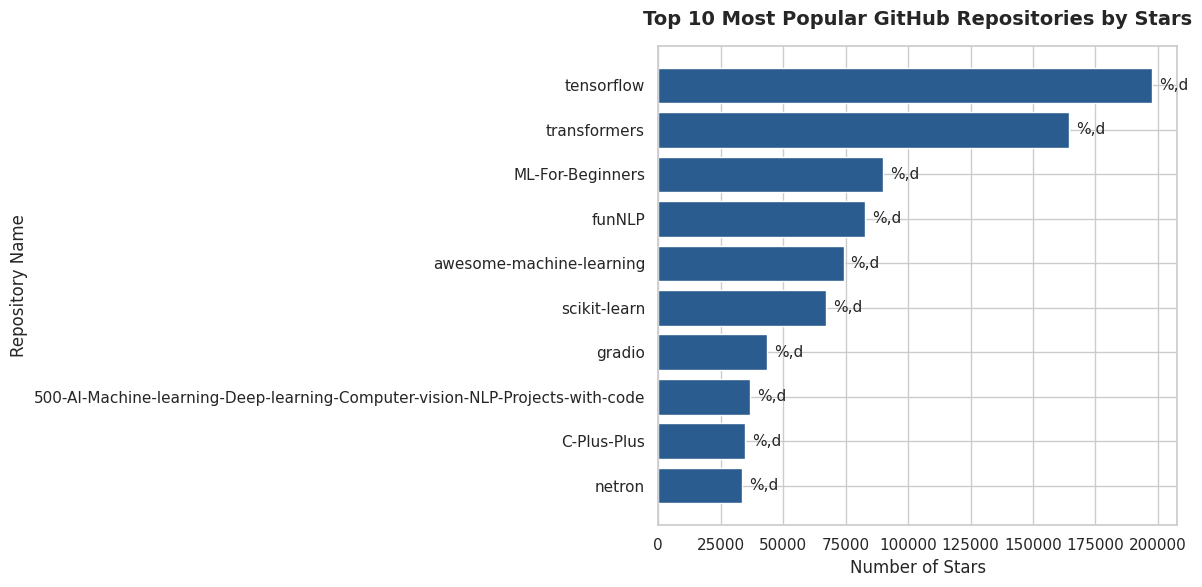

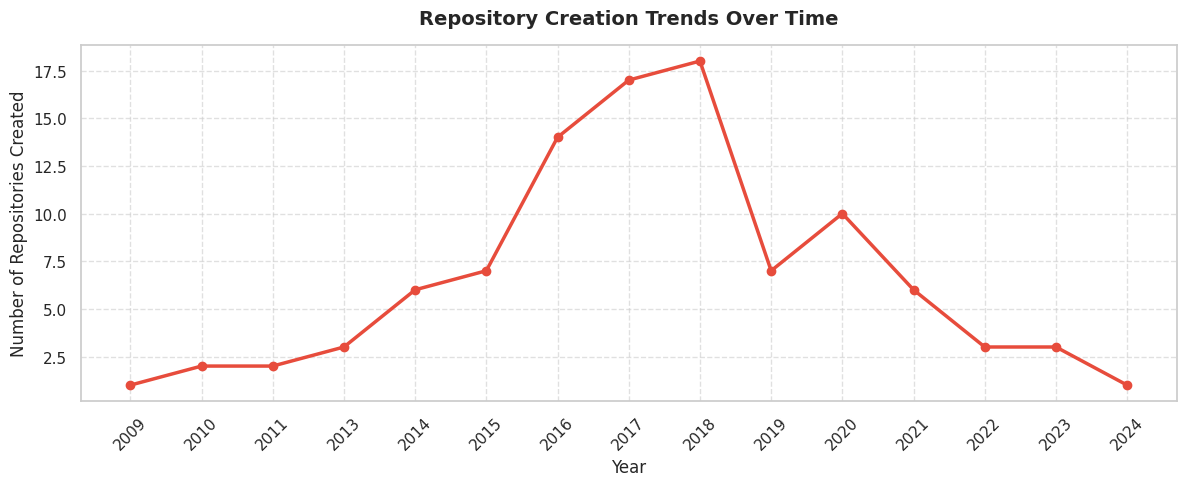

In [161]:
# Task 2 ==================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

# ---------------------------------------------------------
# Visualization 1: Top 10 Most Popular Repositories
# الرسم البياني الأول: أفضل 10 مستودعات من حيث عدد النجوم
# ---------------------------------------------------------

query_top_repos = """
SELECT name, stars
FROM Repositories
ORDER BY stars DESC
LIMIT 10;
"""
df_top_repos = pd.read_sql_query(query_top_repos, conn)

plt.figure(figsize=(12, 6))
bars = plt.barh(df_top_repos['name'], df_top_repos['stars'], color='#2b5c8f')
plt.gca().invert_yaxis()  # Display highest at the top
plt.title('Top 10 Most Popular GitHub Repositories by Stars', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Stars', fontsize=12)
plt.ylabel('Repository Name', fontsize=12)

# Add data values on bars
plt.bar_label(bars, fmt='%,d', padding=5)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Visualization 2: Repository Creation Trends Over Time
# الرسم البياني الثاني: اتجاهات إنشاء المستودعات عبر الزمن
# ---------------------------------------------------------

query_trends = """
SELECT
    strftime('%Y', created_date) AS creation_year,
    COUNT(*) AS repo_count
FROM Repositories
WHERE creation_year IS NOT NULL
GROUP BY creation_year
ORDER BY creation_year ASC;
"""
df_trends = pd.read_sql_query(query_trends, conn)

plt.figure(figsize=(12, 5))
plt.plot(df_trends['creation_year'], df_trends['repo_count'], marker='o', color='#e74c3c', linewidth=2.5, markersize=6)
plt.title('Repository Creation Trends Over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Repositories Created', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Step 8: Interpret Results
## الخطوة الثامنة: تفسير النتائج واستخلاص الرؤى


In [162]:
# Task 2 ==================================================

# Step 8: Interpret Results -------------------------------
# استخراج إحصائيات ملخصة للنتائج من قاعدة البيانات
# Query summary statistics to support our findings

query_insights_data = """
SELECT
    COUNT(*) AS total_repositories,
    ROUND(AVG(stars), 2) AS average_stars,
    MAX(stars) AS max_stars,
    (SELECT language FROM Repositories GROUP BY language ORDER BY COUNT(*) DESC LIMIT 1) AS most_frequent_language,
    (SELECT name FROM Repositories ORDER BY stars DESC LIMIT 1) AS top_starred_repo
FROM Repositories;
"""

df_insights_summary = pd.read_sql_query(query_insights_data, conn)

print("======= Step 8: Key Metrics Summary =======\n")
display(df_insights_summary)

# إغلاق الاتصال بقاعدة البيانات بعد انتهاء Task 2
# Close the SQLite database connection
conn.close()
print("\n✓ SQLite database connection closed successfully.")

======= Step 8: Key Metrics Summary =======



,total_repositories,average_stars,max_stars,most_frequent_language,top_starred_repo
0,100,20850.67,197766,Python,tensorflow



✓ SQLite database connection closed successfully.


###  Key Insights & Findings / أبرز النتائج والرؤى

#### 1. Repository Popularity (شعبية المستودعات)
* **High Concentration of Stars:** The distribution of stars is skewed toward a few dominant repositories (such as the top-starred project), showing that a small percentage of open-source projects capture the majority of developer attention.
* **تركز النجوم:** يتضح من البيانات أن هناك تفاوتاً كبيراً بين متوسط النجوم وأعلى مستودع، مما يدل على أن نسبة قليلة من المشاريع الاستثنائية تحظى بأغلبية اهتمام مجتمع المطورين.

#### 2. Programming Language Trends (اتجاهات لغات البرمجة)
* **Dominant Languages:** Languages like **Python** and **JavaScript** lead the dataset (`HAVING COUNT(*) > 5`). Python's high representation is strongly linked to the popularity of Machine Learning and Data Science tools.
* **اللغات الأكثر انتشاراً:** تتصدر لغات مثل Python و JavaScript البيانات بوضوح، ويرتبط الانتشار الواسع للغة Python بشكل مباشر بانتشار أدوات الذكاء الاصطناعي وتعلم الآلة.

#### 3. Growth & Creation Trends (اتجاهات النمو والإنشاء عبر الزمن)
* **Timeline Patterns:** The line chart reveals specific peak years in repository creation, reflecting historical surges in open-source adoption and developer community activity.
* **النمو عبر الزمن:** يظهر الرسم البياني الخطي فترات ذروة معينة في إنشاء المستودعات، مما يعكس فترات الانتعاش والزيادة في الاعتماد على المصادر المفتوحة.

# Task 3: Manage the Project Using Git and GitHub

# المرحلة الثالثة: إدارة المشروع باستخدام Git و GitHub



## Step 1: Initialize the Git Repository
## الخطوة الأولى: تهيئة مستودع Git المحلي




In [163]:
!git init
!git status

Reinitialized existing Git repository in /content/.git/
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   github_data.db
	modified:   github_projects.csv

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	sample_data/

no changes added to commit (use "git add" and/or "git commit -a")


## Step 2: Stage the Project Files
## الخطوة الثانية: إضافة الملفات لمنطقة الإعداد


In [164]:
# Step 2: Stage the Project Files
!git add github_projects.csv github_data.db
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   github_data.db
	modified:   github_projects.csv

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	sample_data/



## Step 3: Create the First Commit
## الخطوة الثالثة: إنشاء أول حفظ (Commit)


In [165]:
# Step 3: Create the First Commit -------------------------

# 1. إعداد اسم المستخدم والبريد الإلكتروني (مطلوب لـ Git)
# Configure Git user identity
!git config --global user.email "student@example.com"
!git config --global user.name "Student"

# 2. حفظ الملفات المجهزة مع رسالة وصفية
# Create the first commit with a clear descriptive message
!git commit -m "Initial commit: Add SQLite database and dataset"

# 3. التحقق من حالة المستودع بعد الحفظ
# Verify that working tree is clean and changes are saved
!git status

[main 8215b1c] Initial commit: Add SQLite database and dataset
 2 files changed, 7 insertions(+), 7 deletions(-)
On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	sample_data/

nothing added to commit but untracked files present (use "git add" to track)


## Step 4: Create a GitHub Repository
## الخطوة الرابعة: إنشاء مستودع على GitHub

To store and publish our completed project online, we need to create a new remote repository on GitHub. This repository acts as a cloud backup and makes our data analysis work accessible to others.

لتخزين ونشر مشروعنا المكتمل عبر الإنترنت، نحتاج إلى إنشاء مستودع جديد على موقع GitHub. يعمل هذا المستودع كنسخة احتياطية سحابية وتتيح لمجتمع المطورين الاطلاع على مشروع تحليل البيانات.

## Step 5: Connect and Publish the Project
## الخطوة الخامسة: ربط المشروع ونشره على GitHub


In [166]:
# Step 5: Push using Personal Access Token

# 1. ضبط الفرع الرئيسي
!git branch -M main

# 2. حذَف أي رابط قديم لمنع التعارض
!git remote remove origin

# 3. الربط باستخدام اسم حسابك والـ Token بتاعك
# (استبدل YOUR_TOKEN بالرمز اللي عملته)
!git remote add origin https://amrlearn13:@github.com/amrlearn13/github-data-analysis.git

# 4. رفع الملفات
!git push -u origin main

Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 699 bytes | 699.00 KiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/amrlearn13/github-data-analysis.git
   4ea821d..8215b1c  main -> main
Branch 'main' set up to track remote branch 'main' from 'origin'.


## Step 6: Provide Project Evidence
## الخطوة السادسة: تقديم أدلة إنجاز المشروع


**1. Project Links / روابط المشروع**

| Item / العنصر | URL / الرابط |
| :--- | :--- |
| **GitHub Repository** | [github-data-analysis](https://github.com/amrlearn13/github-data-analysis) |

---

**2. Required Screenshots / لقطات الشاشة المطلوبة**

* **Screenshot 01 — Git Initialization & Status**
  * **English:** Shows repository initialization using `git init` and initial status check using `git status`.
  * **عربي:** يوضح تهيئة المستودع والتحقق الأول من الحالة.

* **Screenshot 02 — Staging Files**
  * **English:** Shows project files (`github_projects.csv` and `github_data.db`) successfully added to the Staging Area in green.
  * **عربي:** يوضح إضافة ملفات المشروع إلى منطقة التجهيز باللون الأخضر.

* **Screenshot 03 — First Commit**
  * **English:** Shows the execution of `git commit` with the descriptive message and clean working tree.
  * **عربي:** يوضح تنفيذ أمر الحفظ والتأكيد ورسالة الحفظ.

* **Screenshot 04 — GitHub Repository Online**
  * **English:** Shows the GitHub repository web page with the published files available online.
  * **عربي:** يوضح صفحة المستودع أونلاين بعد نشر الملفات بنجاح.

## Step 7: Complete the Ethics Reflection
## الخطوة السابعة: تأملات في الأخلاقيات وممارسات البيانات



**1. Why is it important to verify data collected from public APIs?**
* **English:** Public APIs can sometimes return outdated, malformed, or unexpected responses due to server errors or rate limits. Verifying the data ensures its accuracy, reliability, and structural integrity before using it in analytical models.
* **عربي:** قد ترجع واجهات برمجة التطبيقات العامة أحياناً بيانات قديمة أو غير صالحة بسبب أخطاء الخوادم. التحقق منها يضمن دقتها وسلامتها الهيكلية قبل استخدامها في التحليل.

**2. Why should data analysts document the source of their data?**
* **English:** Proper documentation ensures transparency, allows other researchers or team members to reproduce the analysis, and establishes the credibility and legal compliance of the data used.
* **عربي:** التوثيق السليم يضمن الشفافية، ويسمح للآخرين بإعادة إنتاج التحليل، ويؤكد مصداقية البيانات والالتزام القانوني باستخدامها.

**3. How can missing or inaccurate data affect data analysis and decision-making?**
* **English:** Missing or corrupted data can introduce severe bias, skew statistical summaries, and lead to misleading insights, ultimately causing decision-makers to implement faulty strategies based on flawed evidence.
* **عربي:** البيانات المفقودة أو غير الدقيقة تسبب تحيزاً شديداً وتشويهاً للإحصائيات، مما يؤدي إلى رؤى مضللة واتخاذ قرارات واستراتيجيات خاطئة بناءً على أدلة معيبة.